In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/dr9/dr9.0/temp/sweep-170p020-180p025.fits'))
print(len(cat))

3703959


In [4]:
maskbits = [1, 8, 9, 11, 12, 13]
min_nobs = 2

cat_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    cat_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~cat_clean)/len(cat_clean))

cat_clean &= (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
print(np.sum(~cat_clean)/len(cat_clean))

cat = cat[cat_clean]
print(len(cat))

0.030241695439933325
0.04672459927337209
3530893


In [6]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gmag = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    rmag = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    zmag = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    w1mag = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    w2mag = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    rfibermag = 22.5 - 2.5*np.log10(cat['FIBERFLUX_R']/cat['MW_TRANSMISSION_R'])
    zfibermag = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']/cat['MW_TRANSMISSION_Z'])
    zfibertotmag = 22.5 - 2.5*np.log10(cat['FIBERTOTFLUX_Z']/cat['MW_TRANSMISSION_Z'])

    gmag[~np.isfinite(gmag)] = 100.
    rmag[~np.isfinite(rmag)] = 100.
    zmag[~np.isfinite(zmag)] = 100.
    w1mag[~np.isfinite(w1mag)] = 100.
    w2mag[~np.isfinite(w2mag)] = 100.
    rfibermag[~np.isfinite(rfibermag)] = 100.
    zfibermag[~np.isfinite(zfibermag)] = 100.
    zfibertotmag[~np.isfinite(zfibertotmag)] = 100.
    
    gflux_ivar = cat['FLUX_IVAR_R']
    
    gaia_g = cat['GAIA_PHOT_G_MEAN_MAG']
    
cat.add_columns([gmag, rmag, zmag, w1mag, w2mag, zfibermag, rfibermag], names=['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'zfibermag', 'rfibermag'])

In [7]:
mask_north = cat['RELEASE']%2==1
mask_south = cat['RELEASE']%2==0

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.6)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.14) * 1.8  # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.3
lrg_mask &= lrg_mask_sliding

mask_lowz = gmag - w1mag > 2.9  # low-z cut
mask_lowz |= rmag - w1mag > 1.8  # low-z cut
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_mask &= (zfibertotmag>17.5)

lrg_final_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.61)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.13) * 1.83  # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.31) * 1.   # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.4
lrg_mask &= lrg_mask_sliding

mask_lowz = gmag - w1mag > 2.97  # low-z cut
mask_lowz |= rmag - w1mag > 1.8  # low-z cut
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_mask &= (zfibertotmag>17.5)

lrg_final_north = lrg_mask.copy()

lrg_final = lrg_final_south | lrg_final_north
print(np.sum(lrg_final))

25508


In [8]:
cat = cat[lrg_final]
print(len(cat))

25508


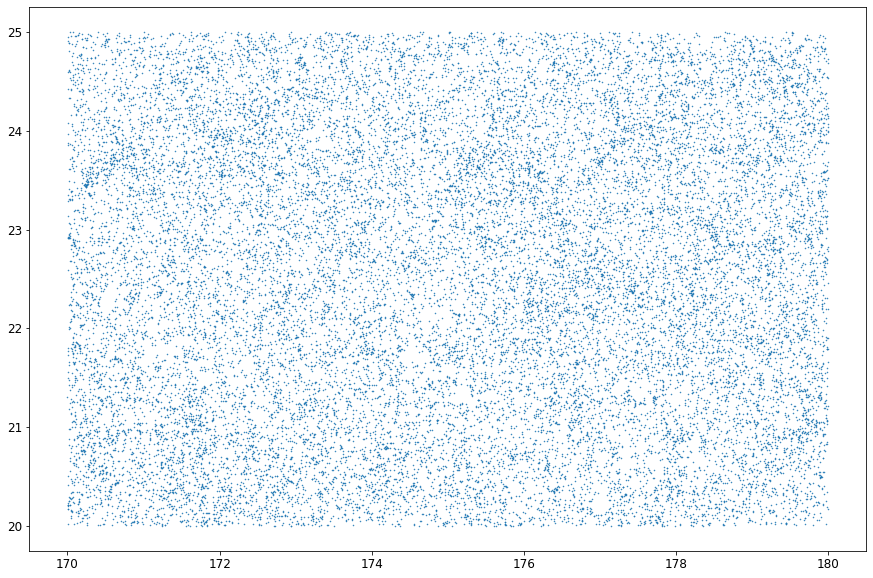

In [9]:
plt.figure(figsize=(15, 10))
plt.plot(cat['RA'], cat['DEC'], '.', ms=1, alpha=1)
# plt.axis([360, 0, -30, 35])
plt.show()

In [12]:
cat[:5]

RELEASE,BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,RA_IVAR,DEC_IVAR,DCHISQ [5],EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_W3,FLUX_W4,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FLUX_IVAR_W3,FLUX_IVAR_W4,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,MW_TRANSMISSION_W3,MW_TRANSMISSION_W4,NOBS_G,NOBS_R,NOBS_Z,NOBS_W1,NOBS_W2,NOBS_W3,NOBS_W4,RCHISQ_G,RCHISQ_R,RCHISQ_Z,RCHISQ_W1,RCHISQ_W2,RCHISQ_W3,RCHISQ_W4,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACFLUX_W1,FRACFLUX_W2,FRACFLUX_W3,FRACFLUX_W4,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,ANYMASK_G,ANYMASK_R,ANYMASK_Z,ALLMASK_G,ALLMASK_R,ALLMASK_Z,WISEMASK_W1,WISEMASK_W2,PSFSIZE_G,PSFSIZE_R,PSFSIZE_Z,PSFDEPTH_G,PSFDEPTH_R,PSFDEPTH_Z,GALDEPTH_G,GALDEPTH_R,GALDEPTH_Z,PSFDEPTH_W1,PSFDEPTH_W2,WISE_COADD_ID,SHAPE_R,SHAPE_R_IVAR,SHAPE_E1,SHAPE_E1_IVAR,SHAPE_E2,SHAPE_E2_IVAR,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,REF_CAT,REF_ID,REF_EPOCH,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_G_MEAN_FLUX_OVER_ERROR,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_BP_MEAN_FLUX_OVER_ERROR,GAIA_PHOT_RP_MEAN_MAG,GAIA_PHOT_RP_MEAN_FLUX_OVER_ERROR,GAIA_ASTROMETRIC_EXCESS_NOISE,GAIA_DUPLICATED_SOURCE,GAIA_PHOT_BP_RP_EXCESS_FACTOR,GAIA_ASTROMETRIC_SIGMA5D_MAX,GAIA_ASTROMETRIC_PARAMS_SOLVED,PARALLAX,PARALLAX_IVAR,PMRA,PMRA_IVAR,PMDEC,PMDEC_IVAR,MASKBITS,FITBITS,SERSIC,SERSIC_IVAR,gmag,rmag,zmag,w1mag,w2mag,zfibermag,rfibermag
int16,int32,str8,int32,str3,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,int16,int16,uint8,uint8,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,str8,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,str2,int64,float32,float32,float32,float32,float32,float32,float32,float32,bool,float32,float32,uint8,float32,float32,float32,float32,float32,float32,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32
9010,460164,1752p230,32,SER,175.1205088054901,23.02912485889771,123519476000.0,105935990000.0,10451.729 .. 13718.574,0.027039321,2.4679708,11.333396,35.867226,80.35929,39.65659,159.55113,-388.68945,91.40411,27.553135,7.4707546,0.9135679,0.27487284,0.0003912314,6.7748206e-06,0.9230777,0.9475103,0.9702913,0.99542814,0.99718976,0.9994,0.9997734,2,2,3,184,183,12,12,0.9642921,1.2328156,1.2167785,8.694572,1.1525578,0.43402007,0.12485017,0.04225283,0.04337621,0.05589412,0.50660473,0.6525147,0.5136342,7.346164,0.096081115,0.09046782,0.09610954,0.7444149,0.7431212,0.7415179,0,0,0,0,0,0,0,0,1.5421555,1.27134,1.5953542,982.4986,402.16183,84.95034,652.3507,231.26279,52.294617,4.3315005,0.78378725,1759p227,5.0960426,180.1667,0.05483163,3128.2915,-0.44655347,6686.5176,0.42512313,1.9522471,6.17835,0.4251279,1.9522741,6.178437,,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,8,6.0,74.32625,21.432245,19.80556,18.580511,17.732435,18.501156,20.490074,21.715122
9010,460164,1752p230,60,DEV,175.1217972104153,22.957221146575872,87500915000.0,74591740000.0,7458.0933 .. 9398.599,0.02615728,0.9523975,5.184642,18.972506,58.923023,31.264126,249.4776,-1126.683,245.34105,73.193726,19.795687,1.6298987,0.45732307,0.00060396444,9.349836e-06,0.925491,0.9491783,0.97124636,0.9955769,0.9972813,0.99941957,0.9997808,3,3,5,192,188,12,13,1.036054,1.0184392,1.0613909,4.514288,1.5000632,0.48614287,0.108258516,0.04851503,0.043227423,0.058283743,0.69136226,1.0208244,0.7636409,5.621058,0.06583594,0.06538821,0.06709325,0.9194631,0.9200171,0.9078257,0,0,0,0,0,0,0,0,1.4023619,1.2020631,1.5941751,1486.0222,575.9152,113.40999,

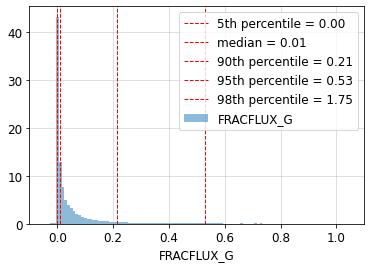

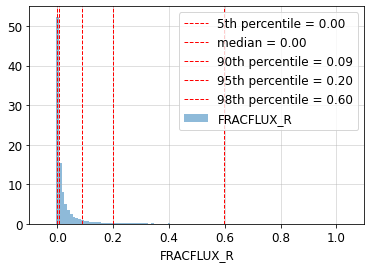

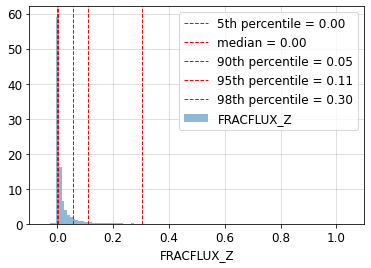

In [35]:
for col in ['FRACFLUX_G', 'FRACFLUX_R', 'FRACFLUX_Z']:
    plt.hist(cat[col], 121, range=(-0.105, 1.105), alpha=0.5, label=col, density=True)
    percentile = 5
    v = np.percentile(cat[col], percentile)
    plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
    v = np.median(cat[col])
    plt.axvline(v, label='median = {:.2f}'.format(v), lw=1, color='r', ls='--')
    percentile = 90
    v = np.percentile(cat[col], percentile)
    plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
    percentile = 95
    v = np.percentile(cat[col], percentile)
    plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
    percentile = 98
    v = np.percentile(cat[col], percentile)
    plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
    plt.grid(alpha=0.5)
    plt.legend(loc='upper right')
    plt.xlabel(col)
    plt.xlim(-0.1, 1.1)
    plt.show()

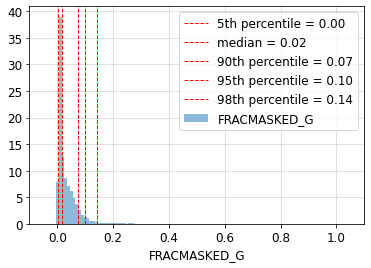

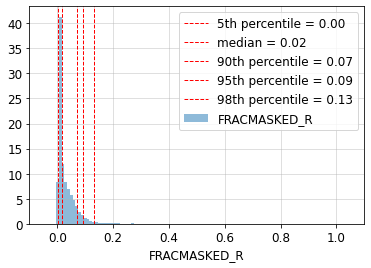

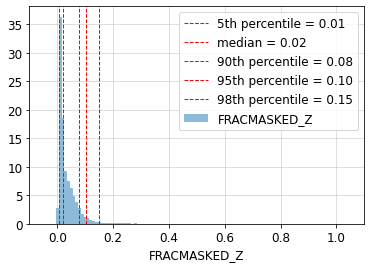

In [34]:
for col in ['FRACMASKED_G', 'FRACMASKED_R', 'FRACMASKED_Z']:
    plt.hist(cat[col], 121, range=(-0.105, 1.105), alpha=0.5, label=col, density=True)
    percentile = 5
    v = np.percentile(cat[col], percentile)
    plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
    v = np.median(cat[col])
    plt.axvline(v, label='median = {:.2f}'.format(v), lw=1, color='r', ls='--')
    percentile = 90
    v = np.percentile(cat[col], percentile)
    plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
    percentile = 95
    v = np.percentile(cat[col], percentile)
    plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
    percentile = 98
    v = np.percentile(cat[col], percentile)
    plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
    plt.grid(alpha=0.5)
    plt.legend(loc='upper right')
    plt.xlabel(col)
    plt.xlim(-0.1, 1.1)
    plt.show()

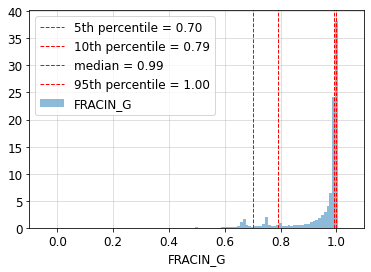

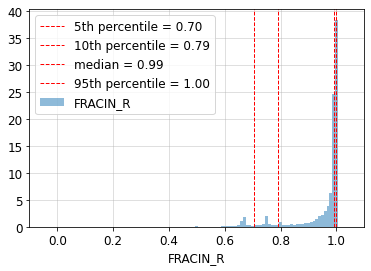

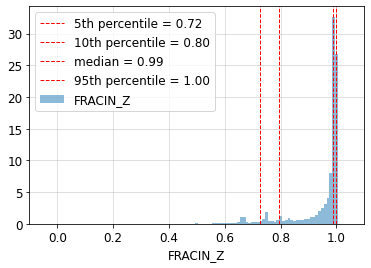

In [42]:
for col in ['FRACIN_G', 'FRACIN_R', 'FRACIN_Z']:
    plt.hist(cat[col], 121, range=(-0.105, 1.105), alpha=0.5, label=col, density=True)
    percentile = 5
    v = np.percentile(cat[col], percentile)
    plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
    percentile = 10
    v = np.percentile(cat[col], percentile)
    plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
    v = np.median(cat[col])
    plt.axvline(v, label='median = {:.2f}'.format(v), lw=1, color='r', ls='--')
    percentile = 95
    v = np.percentile(cat[col], percentile)
    plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
    plt.grid(alpha=0.5)
    plt.legend(loc='upper left')
    plt.xlabel(col)
    plt.xlim(-0.1, 1.1)
    plt.show()

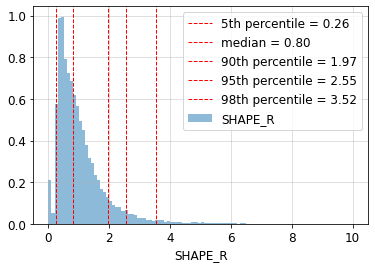

In [46]:
col = 'SHAPE_R'
plt.hist(cat[col], 100, range=(0, 10), alpha=0.5, label=col, density=True)
percentile = 5
v = np.percentile(cat[col], percentile)
plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
v = np.median(cat[col])
plt.axvline(v, label='median = {:.2f}'.format(v), lw=1, color='r', ls='--')
percentile = 90
v = np.percentile(cat[col], percentile)
plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
percentile = 95
v = np.percentile(cat[col], percentile)
plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
percentile = 98
v = np.percentile(cat[col], percentile)
plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.xlabel(col)
# plt.xlim(-0.1, 1.1)
plt.show()

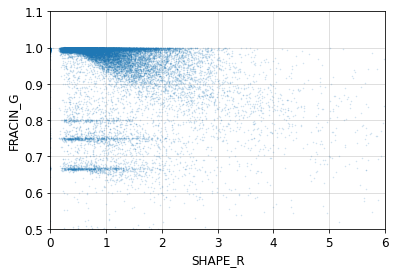

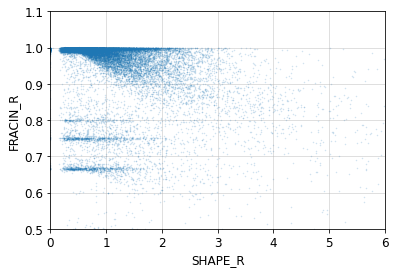

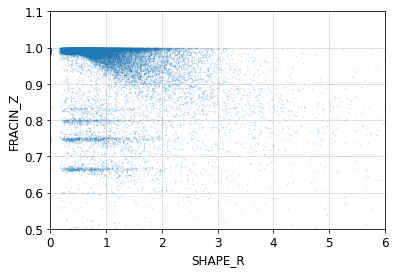

In [58]:
for col in ['FRACIN_G', 'FRACIN_R', 'FRACIN_Z']:
    plt.plot(cat['SHAPE_R'], cat[col], '.', ms=1, alpha=0.2)
    plt.grid(alpha=0.5)
    plt.xlabel('SHAPE_R')
    plt.ylabel(col)
    plt.axis([0, 6, 0.5, 1.1])
    plt.show()

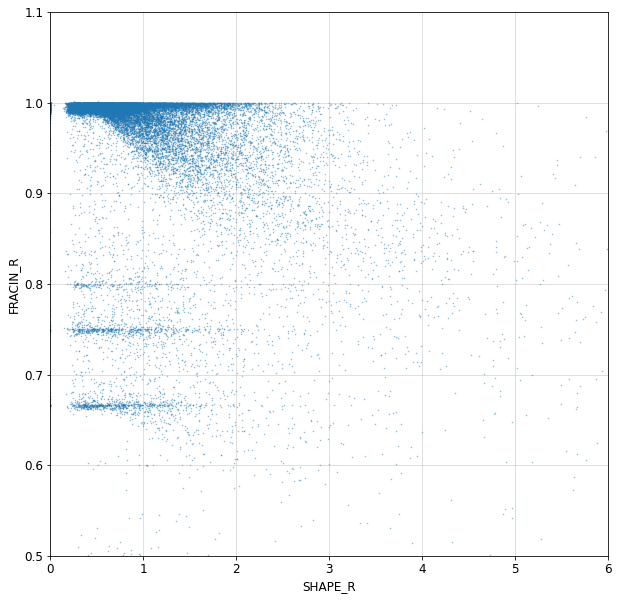

In [60]:
for col in ['FRACIN_R']:
    plt.figure(figsize=(10, 10))
    plt.plot(cat['SHAPE_R'], cat[col], '.', ms=1, alpha=0.5)
    plt.grid(alpha=0.5)
    plt.xlabel('SHAPE_R')
    plt.ylabel(col)
    plt.axis([0, 6, 0.5, 1.1])
    plt.show()

In [88]:
t = Table()
t['type'], t['count'] = np.unique(cat['TYPE'], return_counts=True)
t['frac (%)'] = t['count']/len(cat)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

type,count,frac (%)
str3,int64,float64
PSF,538,2.1
EXP,2881,11.3
SER,3045,11.9
REX,7680,30.1
DEV,11364,44.6


In [69]:
# axis ratio
e = np.array(np.sqrt(cat['SHAPE_E1']**2+cat['SHAPE_E2']**2))
q = (1+e)/(1-e)

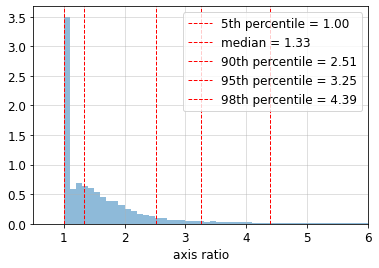

In [79]:
plt.hist(q, 100, range=(0, 10), alpha=0.5, density=True)
percentile = 5
v = np.percentile(q, percentile)
plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
v = np.median(q)
plt.axvline(v, label='median = {:.2f}'.format(v), lw=1, color='r', ls='--')
percentile = 90
v = np.percentile(q, percentile)
plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
percentile = 95
v = np.percentile(q, percentile)
plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
percentile = 98
v = np.percentile(q, percentile)
plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.xlabel('axis ratio')
plt.xlim(0.5, 6)
plt.show()

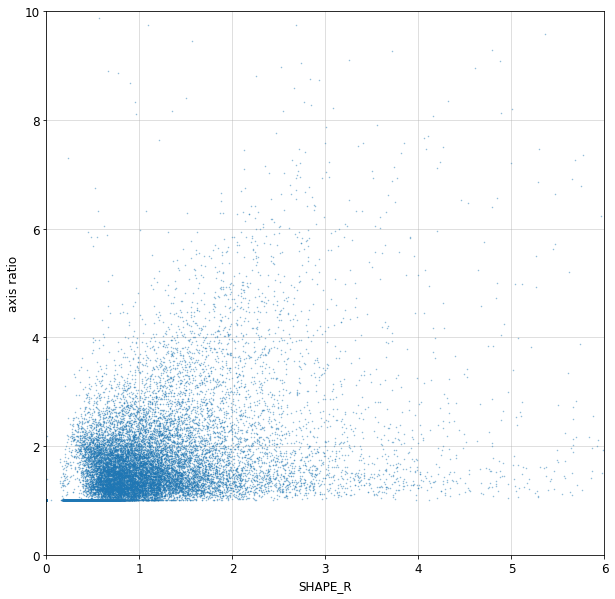

In [73]:
plt.figure(figsize=(10, 10))
plt.plot(cat['SHAPE_R'], q, '.', ms=1, alpha=0.5)
plt.grid(alpha=0.5)
plt.xlabel('SHAPE_R')
plt.ylabel('axis ratio')
plt.axis([0, 6, 0, 10])
plt.show()

In [74]:
# mask = (cat['SHAPE_R']>3) & (q<1.5)
# np.sum(mask)

# idx = np.where(mask)[0]
# print(len(idx))
# if len(idx)>200:
#     idx = np.random.choice(idx, size=200, replace=False)
# t = Table()
# t['RA'] = cat['RA'][idx]
# t['DEC'] = cat['DEC'][idx]
# t.write('/Users/rongpu/Downloads/visual_inspection11.txt', format='ascii.no_header', overwrite=True)

275


--------

In [100]:
faint = cat['zfibermag']>21.5

In [101]:
t = Table()
t['type'], t['count'] = np.unique(cat['TYPE'][faint], return_counts=True)
t['frac (%)'] = t['count']/np.sum(faint)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

type,count,frac (%)
str3,int64,float64
SER,23,0.7
PSF,153,5.0
EXP,427,13.9
DEV,821,26.7
REX,1648,53.6


In [91]:
mask = faint.copy()

idx = np.where(mask)[0]
print(len(idx))
if len(idx)>200:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/Users/rongpu/Downloads/visual_inspection_faint.txt', format='ascii.no_header', overwrite=True)

3072


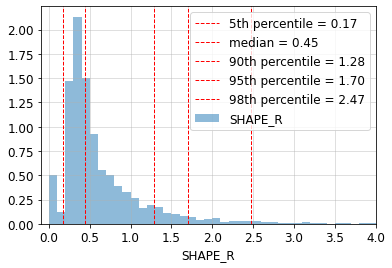

In [129]:
col = 'SHAPE_R'
plt.hist(cat[col][faint], 100, range=(0, 10), alpha=0.5, label=col, density=True)
percentile = 5
v = np.percentile(cat[col][faint], percentile)
plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
v = np.median(cat[col][faint])
plt.axvline(v, label='median = {:.2f}'.format(v), lw=1, color='r', ls='--')
percentile = 90
v = np.percentile(cat[col][faint], percentile)
plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
percentile = 95
v = np.percentile(cat[col][faint], percentile)
plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
percentile = 98
v = np.percentile(cat[col][faint], percentile)
plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.xlabel(col)
plt.xlim(-0.1, 4)
plt.show()

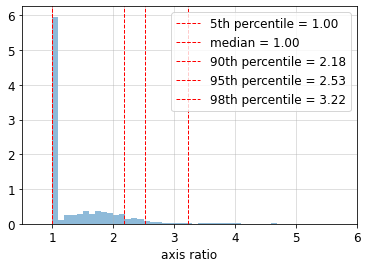

In [95]:
plt.hist(q[faint], 100, range=(0, 10), alpha=0.5, density=True)
percentile = 5
v = np.percentile(q[faint], percentile)
plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
v = np.median(q[faint])
plt.axvline(v, label='median = {:.2f}'.format(v), lw=1, color='r', ls='--')
percentile = 90
v = np.percentile(q[faint], percentile)
plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
percentile = 95
v = np.percentile(q[faint], percentile)
plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
percentile = 98
v = np.percentile(q[faint], percentile)
plt.axvline(v, label='{}th percentile = {:.2f}'.format(percentile, v), lw=1, color='r', ls='--')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.xlabel('axis ratio')
plt.xlim(0.5, 6)
plt.show()

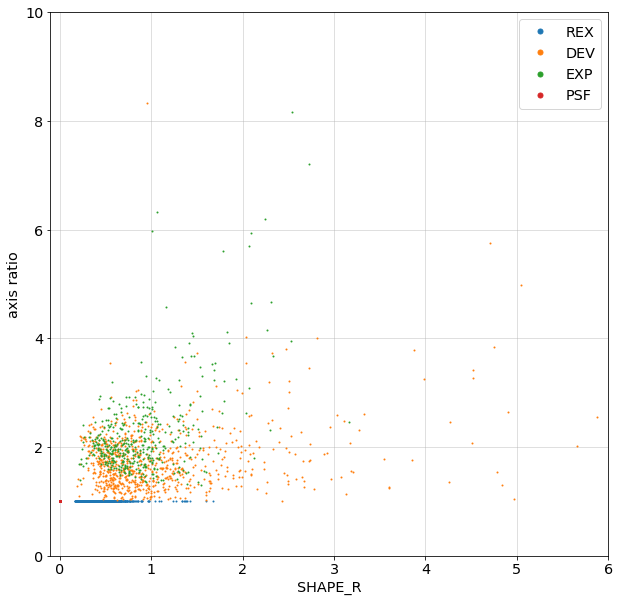

In [137]:
mask_rex = cat['TYPE']=='REX'
mask_dev = cat['TYPE']=='DEV'
mask_exp = cat['TYPE']=='EXP'
mask_psf = cat['TYPE']=='PSF'
plt.figure(figsize=(10, 10))
plt.plot(cat['SHAPE_R'][faint & mask_rex], q[faint & mask_rex], '.', ms=2, alpha=1, label='REX')
plt.plot(cat['SHAPE_R'][faint & mask_dev], q[faint & mask_dev], '.', ms=2, alpha=1, label='DEV')
plt.plot(cat['SHAPE_R'][faint & mask_exp], q[faint & mask_exp], '.', ms=2, alpha=1, label='EXP')
plt.plot(cat['SHAPE_R'][faint & mask_psf], q[faint & mask_psf], '.', ms=2, alpha=1, label='PSF')
plt.grid(alpha=0.5)
plt.xlabel('SHAPE_R')
plt.ylabel('axis ratio')
plt.axis([-0.1, 6, 0, 10])
plt.legend(markerscale=5)
plt.show()

In [94]:
print(np.median(cat['SHAPE_R'][faint]))
print(np.median(q[faint]))

0.44580847
1.0


In [97]:
mask = faint & (cat['TYPE']=='REX')
cat[mask]

RELEASE,BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,RA_IVAR,DEC_IVAR,DCHISQ [5],EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_W3,FLUX_W4,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FLUX_IVAR_W3,FLUX_IVAR_W4,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,MW_TRANSMISSION_W3,MW_TRANSMISSION_W4,NOBS_G,NOBS_R,NOBS_Z,NOBS_W1,NOBS_W2,NOBS_W3,NOBS_W4,RCHISQ_G,RCHISQ_R,RCHISQ_Z,RCHISQ_W1,RCHISQ_W2,RCHISQ_W3,RCHISQ_W4,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACFLUX_W1,FRACFLUX_W2,FRACFLUX_W3,FRACFLUX_W4,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,ANYMASK_G,ANYMASK_R,ANYMASK_Z,ALLMASK_G,ALLMASK_R,ALLMASK_Z,WISEMASK_W1,WISEMASK_W2,PSFSIZE_G,PSFSIZE_R,PSFSIZE_Z,PSFDEPTH_G,PSFDEPTH_R,PSFDEPTH_Z,GALDEPTH_G,GALDEPTH_R,GALDEPTH_Z,PSFDEPTH_W1,PSFDEPTH_W2,WISE_COADD_ID,SHAPE_R,SHAPE_R_IVAR,SHAPE_E1,SHAPE_E1_IVAR,SHAPE_E2,SHAPE_E2_IVAR,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,REF_CAT,REF_ID,REF_EPOCH,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_G_MEAN_FLUX_OVER_ERROR,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_BP_MEAN_FLUX_OVER_ERROR,GAIA_PHOT_RP_MEAN_MAG,GAIA_PHOT_RP_MEAN_FLUX_OVER_ERROR,GAIA_ASTROMETRIC_EXCESS_NOISE,GAIA_DUPLICATED_SOURCE,GAIA_PHOT_BP_RP_EXCESS_FACTOR,GAIA_ASTROMETRIC_SIGMA5D_MAX,GAIA_ASTROMETRIC_PARAMS_SOLVED,PARALLAX,PARALLAX_IVAR,PMRA,PMRA_IVAR,PMDEC,PMDEC_IVAR,MASKBITS,FITBITS,SERSIC,SERSIC_IVAR,gmag,rmag,zmag,w1mag,w2mag,zfibermag,rfibermag
int16,int32,str8,int32,str3,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,int16,int16,uint8,uint8,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,str8,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,str2,int64,float32,float32,float32,float32,float32,float32,float32,float32,bool,float32,float32,uint8,float32,float32,float32,float32,float32,float32,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32
9010,460164,1752p230,2385,REX,175.25166899998007,22.914247307592056,22183363000.0,20391037000.0,1437.2638 .. 0.0,0.02961945,0.21737419,0.9305723,4.170488,25.561611,16.49618,27.361105,-893.3507,934.45953,309.03552,71.04056,2.4921489,0.66429895,0.000866152,1.067557e-05,0.91605437,0.942648,0.9675031,0.994993,0.9969221,0.99934274,0.9997518,3,3,5,190,186,13,12,1.1284953,0.9876134,0.9963747,0.6267288,0.7952835,0.49544263,0.09710869,0.02044789,0.011066099,0.050345708,0.73238915,0.6631364,4.090043,1.841535,0.0042510135,0.004849926,0.012077489,0.9966932,0.99587685,0.9896684,0,0,0,0,0,0,0,0,1.4017856,1.2027957,1.596229,1508.8765,579.49445,113.50455,930.1149,317.41156,71.17636,4.3315005,0.78378725,1759p227,0.43404564,1714.2125,0.0,0.0,0.0,0.0,0.120940834,0.517744,2.320341,0.12097345,0.5178545,2.3209147,,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1.0,0.0,24.061783,22.513998,20.913664,18.97558,19.453194,21.550251,23.150585
9010,460164,1752p230,2402,REX,175.25257966331108,22.913889053976703,18397798000.0,17140408000.0,1398.2891 .. 0.0,0.029611692,0.25893092,0.8768193,4.553426,26.817427,15.338797,93.860374,1037.722,805.4165,264.24298,61.942307,2.4941785,0.66058195,0.0008639735,1.09820985e-05,0.91607535,0.9426626,0.9675114,0.9949943,0.99692285,0.9993429,0.99975187,3,3,5,190,186,13,13,1.0979303,1.0787199,1.052816,0.6622175,0.7400483,0.5576596,0.08890519,0.016529832,0.014788475,0.046797674,0.6699108,0.77467084,0.6808032,0.85127014,0.006006494,0.0062671667,0.014749677,0.9978431,0.9971366,0.9931183,0,0,0,0,0,0,0,0,1.4017856,1.2027957,1.596229,1508.8765,579.49445,113.50455,930.1149,317.4115

In [120]:
mask = cat['TYPE']=='PSF'

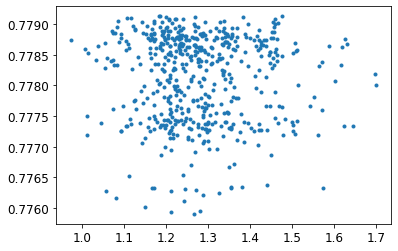

In [121]:
plt.plot(cat['PSFSIZE_R'][mask], (cat['FIBERFLUX_R']/cat['FLUX_R'])[mask], '.')

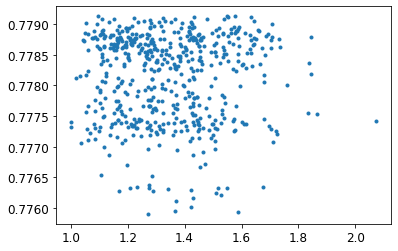

In [122]:
plt.plot(cat['PSFSIZE_Z'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask], '.')

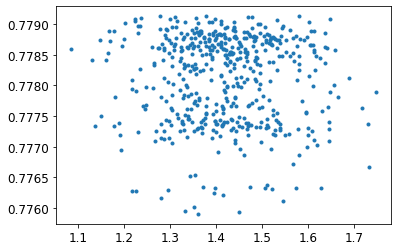

In [119]:
plt.plot(cat['PSFSIZE_G'][mask & (cat['FIBERFLUX_G']>0)], (cat['FIBERFLUX_G']/cat['FLUX_G'])[mask & (cat['FIBERFLUX_G']>0)], '.')

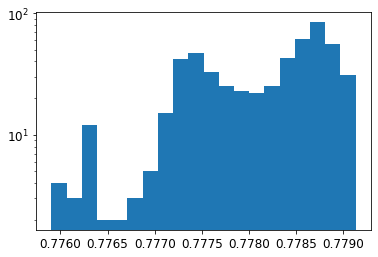

In [124]:
mask = (cat['TYPE']=='PSF')
plt.hist((cat['FIBERFLUX_R'][mask]/cat['FLUX_R'][mask]), 20, log=True)
plt.show()

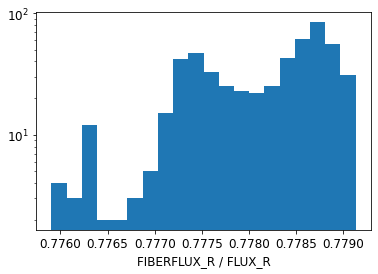

In [126]:
mask = (cat['TYPE']=='PSF')
plt.hist((cat['FIBERFLUX_Z'][mask]/cat['FLUX_Z'][mask]), 20, log=True)
plt.xlabel('FIBERFLUX_R / FLUX_R')
plt.title('LRGs with ')
plt.show()

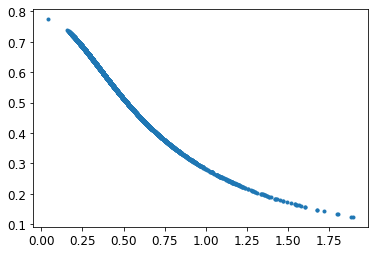

In [131]:
mask = cat['TYPE']=='REX'
plt.plot(cat['SHAPE_R'][mask], (cat['FIBERFLUX_R']/cat['FLUX_R'])[mask], '.')

In [133]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

(0.0, 2.0, 0.1, 0.8)

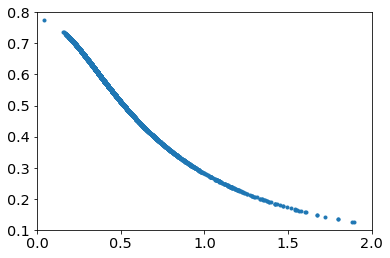

In [134]:
mask = cat['TYPE']=='REX'
plt.plot(cat['SHAPE_R'][mask], (cat['FIBERFLUX_R']/cat['FLUX_R'])[mask], '.')
plt.axis([0, 2., 0.1, 0.8])